# Notebook 03b — Bagging with Decision Tree

### What is Bagging?
Single Decision Tree overfits → high variance.
Bagging fixes this by:

1. Taking the original dataset
2. Creating N **random subsets** (with replacement) → called Bootstrap samples
3. Training one Decision Tree on each subset
4. Final prediction = **average** (regression) or **majority vote** (classification)

### Bagging vs Random Forest:
| | Bagging | Random Forest |
|---|---|---|
| Data sampling | Random subsets ✓ | Random subsets ✓ |
| Feature sampling | ALL features | Random subset of features ✓ |
| Result | Good | Better — more diversity between trees |

Bagging is essentially Random Forest **without** feature randomness.
Understanding Bagging helps you see exactly WHY Random Forest works better.



In [1]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import BaggingRegressor, BaggingClassifier
from sklearn.metrics import (
  r2_score, mean_squared_error, mean_absolute_error,
  accuracy_score, f1_score, classification_report, confusion_matrix
)


In [2]:
with open('processed_data.pkl', 'rb') as f:
  data = pickle.load(f)

X_train       = data['X_train']
X_test        = data['X_test']
y_reg_train   = data['y_reg_train']
y_reg_test    = data['y_reg_test']
y_clf_train   = data['y_clf_train']
y_clf_test    = data['y_clf_test']
le            = data['label_encoder']
feature_names = data['feature_names']

print("Train size:", X_train.shape)
print("Test  size:", X_test.shape)



Train size: (15223, 30)
Test  size: (3806, 30)


## Part 1 — Single Tree vs Bagging (Regression)
Let's directly compare single Decision Tree vs Bagging side by side.

In [3]:
#Single Tree vs Bagging Regressor

# Single Decision Tree
single_tree_reg = DecisionTreeRegressor(random_state=42)
single_tree_reg.fit(X_train, y_reg_train)

r2_single_train = r2_score(y_reg_train, single_tree_reg.predict(X_train))
r2_single_test  = r2_score(y_reg_test,  single_tree_reg.predict(X_test))
rmse_single     = np.sqrt(mean_squared_error(y_reg_test, single_tree_reg.predict(X_test)))

# Bagging with Decision Trees
bag_reg = BaggingRegressor(
  estimator=DecisionTreeRegressor(),
  n_estimators=100,                                           
  max_samples=0.8,      # each tree sees 80% of data
  bootstrap=True,       # sampling with replacement
  random_state=42,
  n_jobs=-1
)
bag_reg.fit(X_train, y_reg_train)

r2_bag_train = r2_score(y_reg_train, bag_reg.predict(X_train))  
r2_bag_test  = r2_score(y_reg_test,  bag_reg.predict(X_test))
rmse_bag     = np.sqrt(mean_squared_error(y_reg_test, bag_reg.predict(X_test)))

print("=== Single Decision Tree ===")
print(f"R² Train : {r2_single_train:.4f}")
print(f"R² Test  : {r2_single_test:.4f}")
print(f"RMSE     : {rmse_single:.2f}")

print("\n=== Bagging (100 Trees) ===")
print(f"R² Train : {r2_bag_train:.4f}")
print(f"R² Test  : {r2_bag_test:.4f}")
print(f"RMSE     : {rmse_bag:.2f}")



=== Single Decision Tree ===
R² Train : 1.0000
R² Test  : 0.9919
RMSE     : 29.12

=== Bagging (100 Trees) ===
R² Train : 0.9981
R² Test  : 0.9952
RMSE     : 22.51


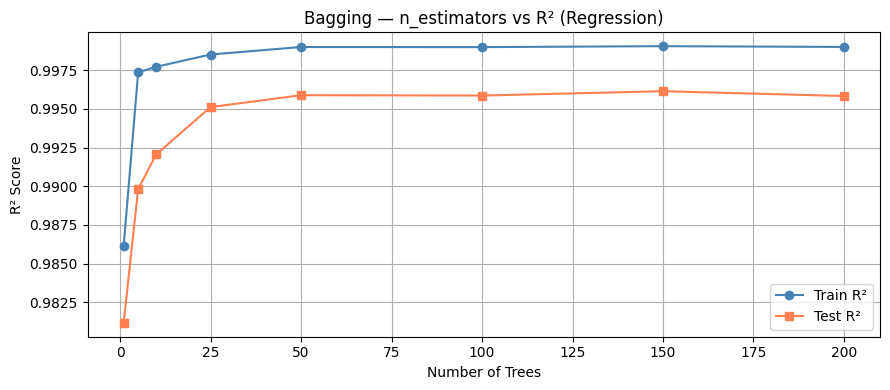

In [4]:
#Effect of n_estimators — Regression

n_trees = [1, 5, 10, 25, 50, 100, 150, 200]
train_scores, test_scores = [], []

for n in n_trees:
  m = BaggingRegressor(
      estimator=DecisionTreeRegressor(),
      n_estimators=n,                                         
      random_state=42,
      n_jobs=-1
  )
  m.fit(X_train, y_reg_train)
  train_scores.append(r2_score(y_reg_train, m.predict(X_train)))
  test_scores.append(r2_score(y_reg_test,   m.predict(X_test)))

plt.figure(figsize=(9, 4))
plt.plot(n_trees, train_scores, marker='o', label='Train R²', color='steelblue')
plt.plot(n_trees, test_scores,  marker='s', label='Test R²',  color='coral')
plt.xlabel('Number of Trees')
plt.ylabel('R² Score')
plt.title('Bagging — n_estimators vs R² (Regression)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


  ## Part 2 — Single Tree vs Bagging (Classification)


In [5]:
#Single Tree vs Bagging Classifier

# Single Decision Tree
single_tree_clf = DecisionTreeClassifier(random_state=42)
single_tree_clf.fit(X_train, y_clf_train)                       

acc_single_train = accuracy_score(y_clf_train, single_tree_clf.predict(X_train))
acc_single_test  = accuracy_score(y_clf_test,  single_tree_clf.predict(X_test))
f1_single        = f1_score(y_clf_test, single_tree_clf.predict(X_test), average='weighted')

# Bagging with Decision Trees
bag_clf = BaggingClassifier(
  estimator=DecisionTreeClassifier(),                         
  n_estimators=100,
  max_samples=0.8,
  bootstrap=True,
  random_state=42,
  n_jobs=-1
)
bag_clf.fit(X_train, y_clf_train)

y_clf_pred = bag_clf.predict(X_test)
acc_bag_train = accuracy_score(y_clf_train, bag_clf.predict(X_train))
acc_bag_test  = accuracy_score(y_clf_test,  y_clf_pred)
f1_bag        = f1_score(y_clf_test, y_clf_pred, average='weighted')

print("=== Single Decision Tree ===")
print(f"Accuracy Train : {acc_single_train:.4f}")
print(f"Accuracy Test  : {acc_single_test:.4f}")
print(f"F1 Score       : {f1_single:.4f}")

print("\n=== Bagging (100 Trees) ===")                          
print(f"Accuracy Train : {acc_bag_train:.4f}")
print(f"Accuracy Test  : {acc_bag_test:.4f}")
print(f"F1 Score       : {f1_bag:.4f}")

=== Single Decision Tree ===
Accuracy Train : 1.0000
Accuracy Test  : 0.9540
F1 Score       : 0.9540

=== Bagging (100 Trees) ===
Accuracy Train : 0.9995
Accuracy Test  : 0.9703
F1 Score       : 0.9703


In [6]:
#Classification Report
print("=== Bagging Classification Report ===")
print(classification_report(
  y_clf_test,
  y_clf_pred,
  target_names=le.classes_
))

=== Bagging Classification Report ===
                         precision    recall  f1-score   support

              Excellent       0.94      0.97      0.95       136
                   Good       0.93      0.94      0.94       317
                   Poor       0.97      0.97      0.97      1066
Unsuitable for Drinking       0.98      0.99      0.99      1370
Very Poor yet Drinkable       0.97      0.95      0.96       917

               accuracy                           0.97      3806
              macro avg       0.96      0.96      0.96      3806
           weighted avg       0.97      0.97      0.97      3806



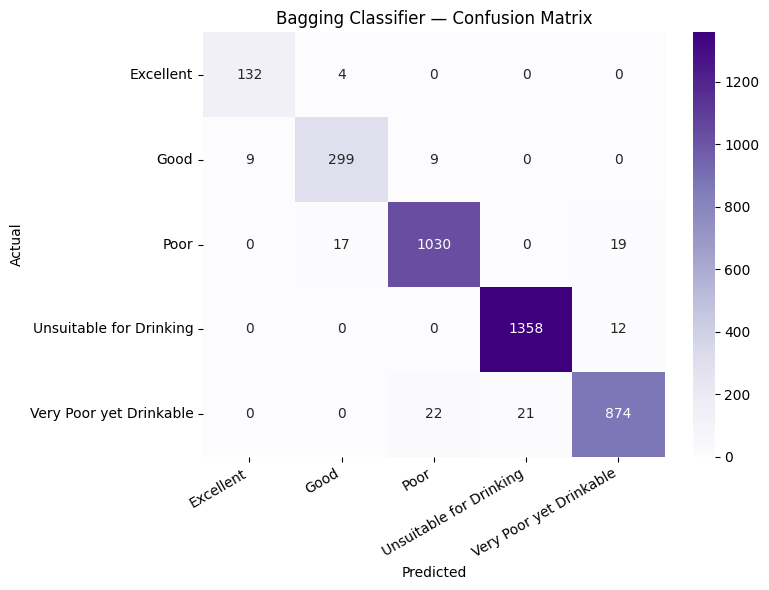

In [7]:
#Confusion Matrix
cm = confusion_matrix(y_clf_test, y_clf_pred)

plt.figure(figsize=(8, 6))                                      
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
          xticklabels=le.classes_,
          yticklabels=le.classes_)
plt.title('Bagging Classifier — Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()                                              
plt.show()


In [8]:
#Full Comparison Table
summary = pd.DataFrame([
  {
      'Model': 'Single Decision Tree',                        
      'Task': 'Regression',
      'Train Score': f"R² = {r2_single_train:.4f}",
      'Test Score':  f"R² = {r2_single_test:.4f}",
      'Gap': round(r2_single_train - r2_single_test, 4)
  },
  {
      'Model': 'Bagging (100 trees)',
      'Task': 'Regression',
      'Train Score': f"R² = {r2_bag_train:.4f}",
      'Test Score':  f"R² = {r2_bag_test:.4f}",
      'Gap': round(r2_bag_train - r2_bag_test, 4)
  },
  {
      'Model': 'Single Decision Tree',                        
      'Task': 'Classification',
      'Train Score': f"Acc = {acc_single_train:.4f}",
      'Test Score':  f"Acc = {acc_single_test:.4f}  F1 = {f1_single:.4f}",
      'Gap': round(acc_single_train - acc_single_test, 4)
  },
  {
      'Model': 'Bagging (100 trees)',
      'Task': 'Classification',                               
      'Train Score': f"Acc = {acc_bag_train:.4f}",
      'Test Score':  f"Acc = {acc_bag_test:.4f}  F1 = {f1_bag:.4f}",
      'Gap': round(acc_bag_train - acc_bag_test, 4)
  }
])

summary


,Model,Task,Train Score,Test Score,Gap
0,Single Decision Tree,Regression,R² = 1.0000,R² = 0.9919,0.0081
1,Bagging (100 trees),Regression,R² = 0.9981,R² = 0.9952,0.0029
2,Single Decision Tree,Classification,Acc = 1.0000,Acc = 0.9540 F1 = 0.9540,0.0460
3,Bagging (100 trees),Classification,Acc = 0.9995,Acc = 0.9703 F1 = 0.9703,0.0292


In [9]:
#Save Results

results = {
  'Bagging Regression': {
      'r2_train': r2_bag_train,
      'r2_test':  r2_bag_test,
      'rmse':     rmse_bag
  },
  'Bagging Classification': {                                 
      'acc_train': acc_bag_train,
      'acc_test':  acc_bag_test,
      'f1_test':   f1_bag
  }
}

with open('results_03b_bagging.pkl', 'wb') as f:
  pickle.dump(results, f)

print("Saved. The Gap column shows how much each model overfits.")
print("Smaller gap = better generalization.")

Saved. The Gap column shows how much each model overfits.
Smaller gap = better generalization.


Single Tree gap  → large  (overfits badly)
Bagging gap      → small  (bootstrap sampling reduces variance)
Random Forest gap → smallest (feature randomness adds even more diversity)

This directly shows you why ensembles beat single trees. 

Bagging (Bootstrap Aggregating)
  
  Sampling WITH replacement

  Dataset: [1, 2, 3, 4, 5]
  Sample 1: [1, 1, 3, 5, 2]  ← 1 appears twice, 4 missing
  Sample 2: [2, 4, 4, 1, 5]  ← 4 appears twice, 3 missing
  Sample 3: [3, 3, 1, 2, 5]  ← 3 appears twice, 4 missing
  Same data point can appear multiple times in one sample.

  ---
  Pasting

  Sampling WITHOUT replacement

  Dataset: [1, 2, 3, 4, 5]
  Sample 1: [1, 3, 5, 2, 4]  ← each appears exactly once
  Sample 2: [2, 4, 1, 5, 3]  ← each appears exactly once
  Sample 3: [3, 1, 4, 2, 5]  ← each appears exactly once
  Each data point appears at most once per sample.

  ---
  Side by side comparison:

  ┌─────────────────────────┬─────────────────────┬─────────────────────┐
  │                         │       Bagging       │       Pasting       │
  ├─────────────────────────┼─────────────────────┼─────────────────────┤
  │ Sampling                │ With replacement    │ Without replacement │
  ├─────────────────────────┼─────────────────────┼─────────────────────┤
  │ Each tree sees          │ ~63% unique samples │ 100% unique samples │
  ├─────────────────────────┼─────────────────────┼─────────────────────┤
  │ Diversity between trees │ Higher              │ Lower               │
  ├─────────────────────────┼─────────────────────┼─────────────────────┤
  │ Bias                    │ Slightly higher     │ Slightly lower      │
  ├─────────────────────────┼─────────────────────┼─────────────────────┤
  │ Variance                │ Lower               │ Higher              │
  ├─────────────────────────┼─────────────────────┼─────────────────────┤
  │ Overfitting risk        │ Lower               │ Higher              │
  ├─────────────────────────┼─────────────────────┼─────────────────────┤
  │ Common in practice      │ Yes — default       │ Rarely used         │
  └─────────────────────────┴─────────────────────┴─────────────────────┘